# Phase 3: Deep Dataset Assessment

A notebook that deep-dives the dataset(s) picked by judgement in Phase 2, and produces a **decision-support** recommendation.

## Design
- **Input:** set `TARGET_DATASETS` manually to CSV(s) under **`src/eda/input/`**.
- **Fast at scale:** VADER-vs-TextBlob reliability and sentiment run on a **sample** (avoids the double full-pass VADER cost of the old pipeline).
- **Key criterion:** surge-definition **viability** (`is_viable`) feeds the final recommendation. A dataset that cannot yield a viable positive class is unsuitable for surge prediction regardless of other stats.
- No imports of project `.py` modules; all analysis is inline.

**Output:** `src/eda/output/deep_assessment.csv` (one row per dataset and surge definition).

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# SETUP (uncomment if needed)
# ══════════════════════════════════════════════════════════════════════════════
# !pip install pandas numpy vaderSentiment textblob

In [3]:
from __future__ import annotations

import csv
import logging
import re
from dataclasses import dataclass, asdict
from datetime import datetime, timezone
from itertools import product
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger("deep")

print("Setup complete.")

Setup complete.


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
current_dir = Path.cwd()
if (current_dir / "src" / "eda").exists():
    PROJECT_ROOT = current_dir
elif current_dir.name == "eda" and (current_dir.parent.parent / "src").exists():
    PROJECT_ROOT = current_dir.parent.parent
else:
    PROJECT_ROOT = current_dir

INPUT_DIR = PROJECT_ROOT / "src" / "eda" / "input"
OUTPUT_DIR = PROJECT_ROOT / "src" / "eda" / "output"
INPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Datasets to assess, using filenames or relative paths under src/eda/input/.
# If this list is left empty, the notebook just uses every CSV found in that
# folder.
TARGET_DATASETS: list[str] = ["leukipp_wallstreetbets/submissions_reddit.csv", "leukipp_pennystocks/submissions_reddit.csv"]

# Sampling sizes and thresholds. Kept fairly small so the notebook runs quickly.
FULL_LOAD_ROWS = 100_000       # most rows loaded for the deep pass (None means load everything)
RELIABILITY_SAMPLE = 3_000     # how many rows are used to check VADER against TextBlob
SURGE_PERCENTILES = [0.90, 0.95, 0.99]
SURGE_STD_DEVS = [0.5, 1.0, 1.5]
MIN_POSITIVE_CLASS_PCT = 2.0   # a surge definition is treated as usable once at least 2% of posts qualify

if TARGET_DATASETS:
    targets = [INPUT_DIR / t for t in TARGET_DATASETS]
else:
    targets = sorted(INPUT_DIR.rglob("*.csv"))

targets = [p for p in targets if p.exists()]
print(f"INPUT_DIR: {INPUT_DIR}")
print(f"Targets ({len(targets)}):")
for p in targets:
    print(f"  - {p.name}")
if not targets:
    print("\nNo target CSVs. Put datasets in src/eda/input/ and/or set TARGET_DATASETS.")

INPUT_DIR: d:\git\uol-bsc-cm3070-final-project\src\eda\input
Targets (2):
  - submissions_reddit.csv
  - submissions_reddit.csv


---
## 1. Inline detectors + ticker extraction

In [5]:
def detect_delimiter(filepath: str, sample_size: int = 8192) -> str:
    try:
        with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
            sample = f.read(sample_size)
        return csv.Sniffer().sniff(sample, delimiters=",;\t|").delimiter
    except (csv.Error, OSError):
        return ","


def detect_date_column(df: pd.DataFrame) -> Optional[str]:
    date_keywords = ["date", "timestamp", "created_at", "created_utc", "time", "posted_at", "created"]
    for col in df.columns:
        if col.lower() in date_keywords:
            return col
    for col in df.columns:
        if any(kw in col.lower() for kw in ["date", "time", "created"]):
            return col
    # Dtype probe (kept in sync with 02_highlevel_eval): if no column name
    # matches, try parsing object/string columns so both notebooks agree on
    # which column is the date when the name is not keyword-matchable.
    for col in df.select_dtypes(include=["object", "string"]).columns:
        sample = df[col].dropna().head(20)
        if len(sample) == 0:
            continue
        parsed = pd.to_datetime(sample, errors="coerce", format="mixed")
        if parsed.notna().sum() >= len(sample) * 0.8:
            return col
    return None


def detect_text_column(df: pd.DataFrame) -> Optional[str]:
    for kw in ["title", "text", "body", "content", "selftext", "comment", "message"]:
        for col in df.columns:
            if col.lower() == kw:
                return col
    return None


def detect_engagement_columns(df: pd.DataFrame) -> list[str]:
    kw = {"likes", "retweets", "comments", "upvotes", "shares", "favorites", "score",
          "num_comments", "comment_count", "like_count", "retweet_count", "ups", "downs", "comms_num"}
    return [c for c in df.columns if c.lower() in kw]


KNOWN_TICKERS = {
    "AAPL", "MSFT", "GOOGL", "GOOG", "AMZN", "TSLA", "META", "NVDA", "AMD", "INTC",
    "NFLX", "DIS", "PYPL", "SQ", "SHOP", "ROKU", "GME", "AMC", "BB", "BBBY", "PLTR",
    "WISH", "CLOV", "SOFI", "SPCE", "NIO", "LCID", "RIVN", "HOOD", "DKNG", "COIN",
    "JPM", "BAC", "GS", "MS", "WFC", "C", "V", "MA", "JNJ", "PFE", "MRNA", "BNTX",
    "SPY", "QQQ", "IWM", "ARKK", "SNDL", "BNGO", "SENS", "PROG", "ATOS", "TNXP",
    "HCMC", "CTRM", "MVIS", "TLRY", "WKHS", "CLNE", "RKT", "UWMC", "CRSR",
}
_FALSE_POSITIVES = {
    "CEO", "IPO", "ETF", "SEC", "FDA", "GDP", "CPI", "ATH", "DD", "EPS", "PE", "RSI",
    "OTC", "NYSE", "IMO", "FYI", "YOLO", "FOMO", "HODL", "WSB", "OP", "TLDR", "US",
    "UK", "EU", "AI", "ML", "IT", "PM", "AM", "THE", "AND", "FOR", "ARE", "BUY",
    "PUT", "CALL", "LONG", "SHORT", "BULL", "BEAR", "MOON", "APE", "HOLD", "SELL",
}
_CASHTAG = re.compile(r"\$([A-Z]{2,5})\b")
_UPPER = re.compile(r"\b([A-Z]{2,5})\b")


def extract_first_ticker(text: str) -> str:
    if not text or not isinstance(text, str):
        return "UNKNOWN"
    for tag in _CASHTAG.findall(text):
        if tag not in _FALSE_POSITIVES:
            return tag
    for word in _UPPER.findall(text):
        if word in KNOWN_TICKERS and word not in _FALSE_POSITIVES:
            return word
    return "UNKNOWN"


print("Detectors + ticker extraction defined.")

Detectors + ticker extraction defined.


---
## 2. Load + prepare one dataset

Loads (capped) rows, normalises the date column, computes VADER sentiment **once**, and extracts a per-row ticker.

In [6]:
def load_prepared(path: Path) -> dict:
    """Load a dataset and get it ready, returning the frame alongside the detected columns."""
    sep = detect_delimiter(str(path))
    df = pd.read_csv(path, sep=sep, engine="python", nrows=FULL_LOAD_ROWS, on_bad_lines="skip")

    date_col = detect_date_column(df)
    text_col = detect_text_column(df)
    eng_cols = detect_engagement_columns(df)

    # Tidy up the date column. It might arrive as Unix seconds or as plain
    # date strings, so both are handled.
    if date_col and date_col in df.columns:
        s = df[date_col]
        if pd.api.types.is_numeric_dtype(s):
            v = s.dropna()
            # Look at the median rather than the first value, since the first row
            # could be 0 or missing and throw off the epoch-seconds guess.
            unit = "s" if (len(v) and abs(v.median()) > 1e9) else None
            df[date_col] = pd.to_datetime(s, unit=unit, errors="coerce") if unit else pd.to_datetime(s, errors="coerce")
        else:
            df[date_col] = pd.to_datetime(s, errors="coerce")

    # Score sentiment with VADER in a single pass over the text.
    sentiment_col = None
    if text_col:
        try:
            from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
            analyzer = SentimentIntensityAnalyzer()
            df["_sentiment"] = df[text_col].fillna("").astype(str).map(
                lambda t: analyzer.polarity_scores(t)["compound"]
            )
            sentiment_col = "_sentiment"
        except ImportError:
            logger.warning("vaderSentiment not installed; sentiment analysis skipped.")

    # Pull out a ticker for each row from its text.
    if text_col:
        df["_ticker"] = df[text_col].map(extract_first_ticker)
    else:
        df["_ticker"] = "UNKNOWN"

    return {
        "df": df, "date_col": date_col, "text_col": text_col,
        "engagement_cols": eng_cols, "sentiment_col": sentiment_col,
    }


print("load_prepared defined.")

load_prepared defined.


---
## 3. Data quality + temporal coverage

In [7]:
def data_quality(df: pd.DataFrame) -> dict:
    total = len(df)
    missing = {c: round(float(df[c].isna().mean()) * 100, 2) for c in df.columns}
    high_risk = [c for c, pct in missing.items() if pct > 30.0]
    return {
        "record_count": total,
        "column_count": df.shape[1],
        "high_risk_columns": high_risk,
        "duplicate_rows": int(df.duplicated().sum()),
        # Full per-column missing % (added so the figures section can draw a
        # missingness bar). high_risk_columns above is derived from this.
        "missing_pct": missing,
    }


def temporal_coverage(df: pd.DataFrame, date_col: Optional[str]) -> dict:
    if not date_col or date_col not in df.columns:
        return {"date_range": ("unknown", "unknown"), "total_days": 0, "gap_count": 0}
    dts = df[date_col].dropna().sort_values().reset_index(drop=True)
    if len(dts) < 2:
        return {"date_range": ("unknown", "unknown"), "total_days": 0, "gap_count": 0}
    gaps = int((dts.diff() > pd.Timedelta(days=7)).sum())
    return {
        "date_range": (str(dts.iloc[0].date()), str(dts.iloc[-1].date())),
        "total_days": int((dts.iloc[-1] - dts.iloc[0]).days),
        "gap_count": gaps,
    }


print("Quality + temporal helpers defined.")

Quality + temporal helpers defined.


---
## 4. Sentiment reliability (sampled)

VADER-vs-TextBlob agreement on a small sample only, which keeps runtime short on large datasets.

In [8]:
def sentiment_reliability(df: pd.DataFrame, text_col: Optional[str],
                          sentiment_col: Optional[str]) -> dict:
    if not text_col or not sentiment_col:
        return {"agreement_rate": None, "note": "no text/sentiment column"}
    try:
        from textblob import TextBlob
    except ImportError:
        return {"agreement_rate": None, "note": "textblob not installed"}

    sample = df[[text_col, sentiment_col]].dropna().head(RELIABILITY_SAMPLE)
    if sample.empty:
        return {"agreement_rate": None, "note": "empty sample"}

    def _cls(x: float) -> int:
        return 1 if x > 0.05 else (-1 if x < -0.05 else 0)

    vader_cls = sample[sentiment_col].map(_cls)
    tb_cls = sample[text_col].astype(str).map(lambda t: _cls(TextBlob(t).sentiment.polarity))
    agreement = float((vader_cls.values == tb_cls.values).mean())
    return {
        "agreement_rate": round(agreement, 4),
        "sample_size": int(len(sample)),
        "note": "good" if agreement >= 0.7 else ("moderate" if agreement >= 0.5 else "low"),
    }


print("sentiment_reliability defined.")

sentiment_reliability defined.


---
## 5. Surge-definition viability sweep

For each (percentile x std-dev) combo, compute the positive-class rate and flag `is_viable` (>= `MIN_POSITIVE_CLASS_PCT`). This is the deciding factor for a surge-prediction dataset.

Two things to keep in mind when reading these numbers:
- **This is a per-post check, not a time-windowed one.** A post is counted as a surge when its own engagement clears the per-ticker percentile *and* its sentiment deviates enough. There is no 24-hour bucketing here; the sweep is a cheap proxy for whether a viable positive class exists at all.
- **Posts with no detectable ticker all land in one `UNKNOWN` group.** They get normalised against each other rather than against a real ticker, which is noisier, and they still count toward the total. For text like Reddit titles this bucket can be large, so treat the exact percentages as indicative rather than precise.

In [9]:
@dataclass
class SurgeResult:
    engagement_percentile: float
    sentiment_std_devs: float
    surge_count: int
    total_posts: int
    surge_percentage: float
    is_viable: bool


def surge_viability_sweep(df: pd.DataFrame, engagement_cols: list[str],
                          sentiment_col: Optional[str], date_col: Optional[str],
                          ticker_col: str = "_ticker") -> list[SurgeResult]:
    results: list[SurgeResult] = []
    if not engagement_cols or not sentiment_col or not date_col:
        return results

    work = df.copy()
    work[date_col] = pd.to_datetime(work[date_col], errors="coerce")
    total = len(work)

    # For each ticker, z-normalise every engagement column and then take the
    # strongest signal across them.
    norm_frames = []
    for col in engagement_cols:
        series = pd.to_numeric(work[col], errors="coerce")
        grp = series.groupby(work[ticker_col])
        mean = grp.transform("mean")
        std = grp.transform("std").replace(0, np.nan)
        norm_frames.append(((series - mean) / std).fillna(0.0))
    eng_norm = pd.concat(norm_frames, axis=1).max(axis=1) if norm_frames else pd.Series(0.0, index=work.index)

    # Measure how far each post's sentiment sits from its ticker's usual level.
    sent = pd.to_numeric(work[sentiment_col], errors="coerce")
    sgrp = sent.groupby(work[ticker_col])
    sent_mean = sgrp.transform("mean")
    sent_std = sgrp.transform("std").replace(0, np.nan)
    sent_dev = ((sent - sent_mean).abs() / sent_std).fillna(0.0)

    for pct, sd in product(SURGE_PERCENTILES, SURGE_STD_DEVS):
        eng_thresh = eng_norm.groupby(work[ticker_col]).transform(lambda x: x.quantile(pct))
        eng_hit = eng_norm >= eng_thresh
        sent_hit = sent_dev >= sd
        surge = (eng_hit & sent_hit)
        count = int(surge.sum())
        pct_pos = round((count / total) * 100, 2) if total else 0.0
        results.append(SurgeResult(
            engagement_percentile=pct, sentiment_std_devs=sd,
            surge_count=count, total_posts=total, surge_percentage=pct_pos,
            is_viable=pct_pos >= MIN_POSITIVE_CLASS_PCT,
        ))
    return results


print("surge_viability_sweep defined.")

surge_viability_sweep defined.


---
## 6. Assess each target dataset

The recommendation is driven by surge viability first: **suitable** only if at least one surge definition is viable AND the surge-label fields exist. Other stats (missingness, duplicates, temporal gaps, sentiment reliability) are reported as supporting risks.

In [10]:
def assess_one(path: Path) -> dict:
    prep = load_prepared(path)
    df = prep["df"]
    quality = data_quality(df)
    temporal = temporal_coverage(df, prep["date_col"])
    reliability = sentiment_reliability(df, prep["text_col"], prep["sentiment_col"])
    surges = surge_viability_sweep(
        df, prep["engagement_cols"], prep["sentiment_col"], prep["date_col"]
    )
    viable = [s for s in surges if s.is_viable]

    # Collect anything about the dataset that's worth flagging.
    risks: list[str] = []
    if quality["record_count"] < 5_000:
        risks.append(f"Small sample ({quality['record_count']} rows loaded).")
    if quality["high_risk_columns"]:
        risks.append(f"High-missing columns: {quality['high_risk_columns']}.")
    if quality["duplicate_rows"] > 0:
        risks.append(f"{quality['duplicate_rows']} duplicate rows.")
    if temporal["gap_count"] > 0:
        risks.append(f"{temporal['gap_count']} temporal gap(s) > 7 days.")
    if reliability.get("agreement_rate") is not None and reliability["agreement_rate"] < 0.5:
        risks.append("Low VADER/TextBlob sentiment agreement.")

    surge_fields_ready = bool(prep["engagement_cols"]) and bool(prep["sentiment_col"]) and bool(prep["date_col"])

    # This is the crux: whether any surge definition is viable decides the verdict.
    if not surge_fields_ready:
        recommendation = "unsuitable"
        justification = "Missing fields required to build surge labels (need engagement + text/sentiment + date)."
    elif not viable:
        recommendation = "unsuitable"
        justification = (
            f"No surge definition reaches the {MIN_POSITIVE_CLASS_PCT}% viable positive-class threshold; "
            "class too sparse for reliable learning."
        )
    else:
        recommendation = "suitable"
        best = max(viable, key=lambda s: s.surge_percentage)
        justification = (
            f"{len(viable)}/{len(surges)} surge definitions viable; best positive class "
            f"{best.surge_percentage}% at p={best.engagement_percentile}, std={best.sentiment_std_devs}."
        )

    return {
        # Prefix the folder name so two files sharing a name (like the two
        # 'submissions_reddit.csv' files) stay distinct in the report and CSV.
        "dataset": f"{path.parent.name}/{path.stem}",
        "path": str(path.relative_to(INPUT_DIR)),
        "detected_columns": {
            "date": prep["date_col"], "text": prep["text_col"],
            "engagement": prep["engagement_cols"], "sentiment": prep["sentiment_col"],
        },
        "quality": quality,
        "temporal": temporal,
        "sentiment_reliability": reliability,
        "surge_definitions": [asdict(s) for s in surges],
        "viable_surge_count": len(viable),
        "surge_fields_ready": surge_fields_ready,
        "risks": risks,
        "recommendation": recommendation,
        "justification": justification,
    }


assessments = []
for path in targets:
    print(f"Assessing {path.name} ...")
    try:
        assessments.append(assess_one(path))
    except Exception as e:
        logger.warning("Assessment failed for %s: %s", path.name, e)

print(f"\nAssessed {len(assessments)} dataset(s).")

Assessing submissions_reddit.csv ...
Assessing submissions_reddit.csv ...

Assessed 2 dataset(s).


---
## 7. Report

In [11]:
for a in assessments:
    print("=" * 64)
    print(f"DATASET: {a['dataset']}")
    print("=" * 64)
    q, t = a["quality"], a["temporal"]
    print(f"Records loaded:  {q['record_count']:,}  |  columns: {q['column_count']}")
    print(f"Date range:      {t['date_range'][0]} -> {t['date_range'][1]}  ({t['total_days']} days, {t['gap_count']} gaps)")
    print(f"Detected cols:   {a['detected_columns']}")
    rel = a["sentiment_reliability"]
    print(f"Sentiment agree: {rel.get('agreement_rate')} ({rel.get('note')})")
    print(f"Viable surges:   {a['viable_surge_count']}/{len(a['surge_definitions'])}")
    if a["risks"]:
        print("Risks:")
        for r in a["risks"]:
            print(f"  - {r}")
    print(f"\n>>> RECOMMENDATION: {a['recommendation'].upper()}")
    print(f"    {a['justification']}")
    print()

if assessments:
    surge_rows = []
    for a in assessments:
        for s in a["surge_definitions"]:
            surge_rows.append({"dataset": a["dataset"], **s})
    if surge_rows:
        print("Surge viability detail:")
        display(pd.DataFrame(surge_rows))

DATASET: leukipp_wallstreetbets/submissions_reddit
Records loaded:  100,000  |  columns: 26
Date range:      2021-01-01 -> 2021-01-28  (27 days, 0 gaps)
Detected cols:   {'date': 'created', 'text': 'title', 'engagement': ['score', 'num_comments'], 'sentiment': '_sentiment'}
Sentiment agree: 0.661 (moderate)
Viable surges:   3/9

>>> RECOMMENDATION: SUITABLE
    3/9 surge definitions viable; best positive class 5.0% at p=0.9, std=0.5.

DATASET: leukipp_pennystocks/submissions_reddit
Records loaded:  54,785  |  columns: 26
Date range:      2021-01-01 -> 2021-12-31  (364 days, 0 gaps)
Detected cols:   {'date': 'created', 'text': 'title', 'engagement': ['score', 'num_comments'], 'sentiment': '_sentiment'}
Sentiment agree: 0.723 (good)
Viable surges:   4/9

>>> RECOMMENDATION: SUITABLE
    4/9 surge definitions viable; best positive class 5.8% at p=0.9, std=0.5.

Surge viability detail:


,dataset,engagement_percentile,sentiment_std_devs,surge_count,total_posts,surge_percentage,is_viable
0,leukipp_wallstreetbets/submissions_reddit,0.90,0.5,4997,100000,5.00,True
1,leukipp_wallstreetbets/submissions_reddit,0.90,1.0,3566,100000,3.57,True
2,leukipp_wallstreetbets/submissions_reddit,0.90,1.5,1970,100000,1.97,False
3,leukipp_wallstreetbets/submissions_reddit,0.95,0.5,2618,100000,2.62,True
4,leukipp_wallstreetbets/submissions_reddit,0.95,1.0,1796,100000,1.80,False
5,leukipp_wallstreetbets/submissions_reddit,0.95,1.5,982,100000,0.98,False
6,leukipp_wallstreetbets/submissions_reddit,0.99,0.5,692,100000,0.69,False
7,leukipp_wallstreetbets/submissions_reddit,0.99,1.0,391,100000,0.39,False
8,leukipp_wallstreetbets/submissions_reddit,0.99,1.5,191,100000,0.19,False
9,leukipp_pennystocks/submissions_reddit,0.90,0.5,3177,54785,5.80,True


---
## 8. Decision-support figures

These figures exist to **defend the dataset-pickup decision** from Phase 2/3, not to
re-run the analysis. They render only the numbers already computed above, so they add
no extra data passes. If `matplotlib` is not installed the section prints a notice and
skips cleanly (the notebook keeps its "no heavy deps required" promise).

Figures produced per assessed dataset, plus one cross-dataset comparison:

1. **Surge-viability heatmap** — `surge_percentage` across the (engagement percentile x
   sentiment std-dev) grid, with viable cells (>= threshold) outlined. This visualises the
   single criterion that drives the verdict.
2. **Missingness bar** — per-column missing %, with the 30%% high-risk line marked.
3. **Cross-dataset comparison** — records loaded, days of coverage, temporal gaps, and
   viable-definition count side by side, so the chosen dataset can be justified against
   the alternatives.

**Read the surge numbers with the same caveats as the sweep above:** they come from a
per-post proxy (no 24h windowing), and posts with no detected ticker all share one noisy
`UNKNOWN` group. Treat the percentages as indicative, not exact.


In [12]:
# ---------------------------------------------------------------------------
# Figure helpers. Guarded so the notebook still runs end-to-end without
# matplotlib installed; in that case plotting is skipped, not fatal.
# ---------------------------------------------------------------------------
try:
    import matplotlib
    matplotlib.use("Agg") if False else None  # keep default backend in notebooks
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle
    _HAS_MPL = True
except ImportError:
    _HAS_MPL = False
    logger.warning("matplotlib not installed; figure section will be skipped.")

# Where figures are written. Kept alongside the CSV artifacts.
FIGURES_DIR = OUTPUT_DIR / "figures"
SAVE_FIGURES = True  # set False to only display inline, not write PNGs


def _safe_name(dataset: str) -> str:
    """Turn a 'folder/stem' dataset id into a filesystem-safe slug."""
    return re.sub(r"[^0-9A-Za-z._-]+", "_", dataset).strip("_")


def _savefig(fig, filename: str) -> None:
    if SAVE_FIGURES:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURES_DIR / filename, dpi=120, bbox_inches="tight")


def plot_surge_viability_heatmap(assessment: dict):
    """Heatmap of surge_percentage over the (percentile x std-dev) grid.

    Viable cells (>= MIN_POSITIVE_CLASS_PCT) are outlined so the reader can see
    at a glance which surge definitions clear the bar that drives the verdict.
    """
    defs = assessment.get("surge_definitions") or []
    if not defs:
        print(f"  [{assessment['dataset']}] no surge definitions to plot.")
        return
    pcts = sorted({d["engagement_percentile"] for d in defs})
    sds = sorted({d["sentiment_std_devs"] for d in defs})
    grid = np.full((len(sds), len(pcts)), np.nan)
    viable = np.zeros_like(grid, dtype=bool)
    lookup = {(d["engagement_percentile"], d["sentiment_std_devs"]): d for d in defs}
    for i, sd in enumerate(sds):
        for j, pc in enumerate(pcts):
            d = lookup.get((pc, sd))
            if d is not None:
                grid[i, j] = d["surge_percentage"]
                viable[i, j] = bool(d["is_viable"])

    fig, ax = plt.subplots(figsize=(1.6 * len(pcts) + 2, 1.2 * len(sds) + 2))
    im = ax.imshow(grid, cmap="YlOrRd", aspect="auto", origin="lower")
    ax.set_xticks(range(len(pcts)))
    ax.set_xticklabels([f"p{int(p * 100)}" for p in pcts])
    ax.set_yticks(range(len(sds)))
    ax.set_yticklabels([f"{s}σ" for s in sds])
    ax.set_xlabel("Engagement percentile")
    ax.set_ylabel("Sentiment std-devs")
    ax.set_title(f"Surge-viability grid — {assessment['dataset']}\n"
                 f"(cell = positive-class %, outlined = viable ≥ {MIN_POSITIVE_CLASS_PCT}%)")
    for i in range(len(sds)):
        for j in range(len(pcts)):
            if not np.isnan(grid[i, j]):
                ax.text(j, i, f"{grid[i, j]:.2f}%", ha="center", va="center",
                        fontsize=9, color="black")
            if viable[i, j]:
                ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                       edgecolor="#1a7f37", linewidth=2.5))
    fig.colorbar(im, ax=ax, label="Positive-class %")
    plt.tight_layout()
    _savefig(fig, f"surge_viability_{_safe_name(assessment['dataset'])}.png")
    plt.show()


def plot_missingness(assessment: dict, top_n: int = 20):
    """Per-column missing % bar, with the 30% high-risk threshold marked."""
    missing = (assessment.get("quality") or {}).get("missing_pct") or {}
    if not missing:
        print(f"  [{assessment['dataset']}] no missing-value data to plot.")
        return
    items = sorted(missing.items(), key=lambda kv: kv[1], reverse=True)[:top_n]
    cols = [c for c, _ in items]
    vals = [v for _, v in items]
    colors = ["#e74c3c" if v > 30.0 else "#5b8def" for v in vals]

    fig, ax = plt.subplots(figsize=(10, max(3, 0.4 * len(cols) + 1)))
    ax.barh(range(len(cols)), vals, color=colors)
    ax.set_yticks(range(len(cols)))
    ax.set_yticklabels(cols)
    ax.invert_yaxis()
    ax.set_xlabel("Missing %")
    ax.set_xlim(0, max(100, max(vals) * 1.1) if vals else 100)
    ax.axvline(30.0, color="#e74c3c", linestyle="--", linewidth=1,
               label="30% high-risk line")
    ax.set_title(f"Missing values by column — {assessment['dataset']}")
    ax.legend(loc="lower right")
    plt.tight_layout()
    _savefig(fig, f"missingness_{_safe_name(assessment['dataset'])}.png")
    plt.show()


def plot_cross_dataset_comparison(assessments: list):
    """Side-by-side comparison of the assessed datasets on the metrics that
    matter for the pickup decision: records loaded, days of coverage, temporal
    gaps, and how many surge definitions are viable."""
    if len(assessments) < 1:
        print("  no assessments to compare.")
        return
    names = [a["dataset"] for a in assessments]
    records = [(a.get("quality") or {}).get("record_count", 0) for a in assessments]
    days = [(a.get("temporal") or {}).get("total_days", 0) for a in assessments]
    gaps = [(a.get("temporal") or {}).get("gap_count", 0) for a in assessments]
    viable = [a.get("viable_surge_count", 0) for a in assessments]

    panels = [
        ("Records loaded", records, "#5b8def"),
        ("Days of coverage", days, "#1a7f37"),
        ("Temporal gaps (>7d)", gaps, "#e67e22"),
        ("Viable surge defs", viable, "#8e44ad"),
    ]
    fig, axes = plt.subplots(1, len(panels), figsize=(4.2 * len(panels), 4.2), squeeze=False)
    x = range(len(names))
    for ax, (title, vals, color) in zip(axes[0], panels):
        ax.bar(x, vals, color=color)
        ax.set_xticks(list(x))
        ax.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
        ax.set_title(title, fontsize=11)
        for xi, v in zip(x, vals):
            ax.text(xi, v, f"{v:,}" if isinstance(v, int) else f"{v}",
                    ha="center", va="bottom", fontsize=8)
    fig.suptitle("Cross-dataset comparison (decision support)", fontsize=13, y=1.03)
    plt.tight_layout()
    _savefig(fig, "cross_dataset_comparison.png")
    plt.show()


print("Figure helpers defined." if _HAS_MPL else "Figure helpers defined (matplotlib missing; plotting will skip).")


Figure helpers defined.


Figures for leukipp_wallstreetbets/submissions_reddit (recommendation: suitable)


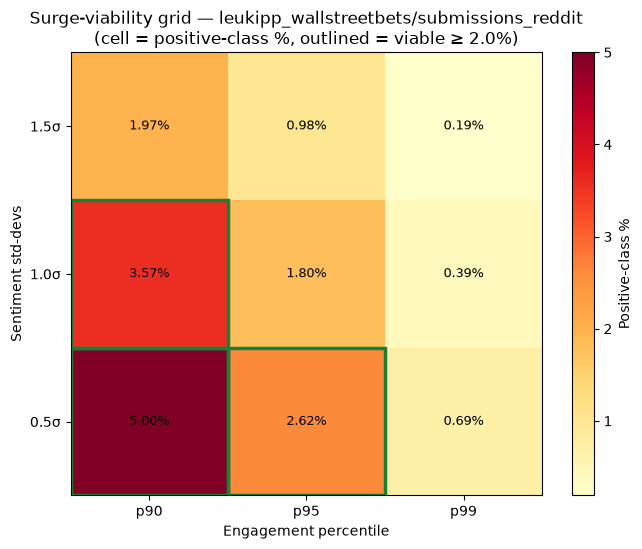

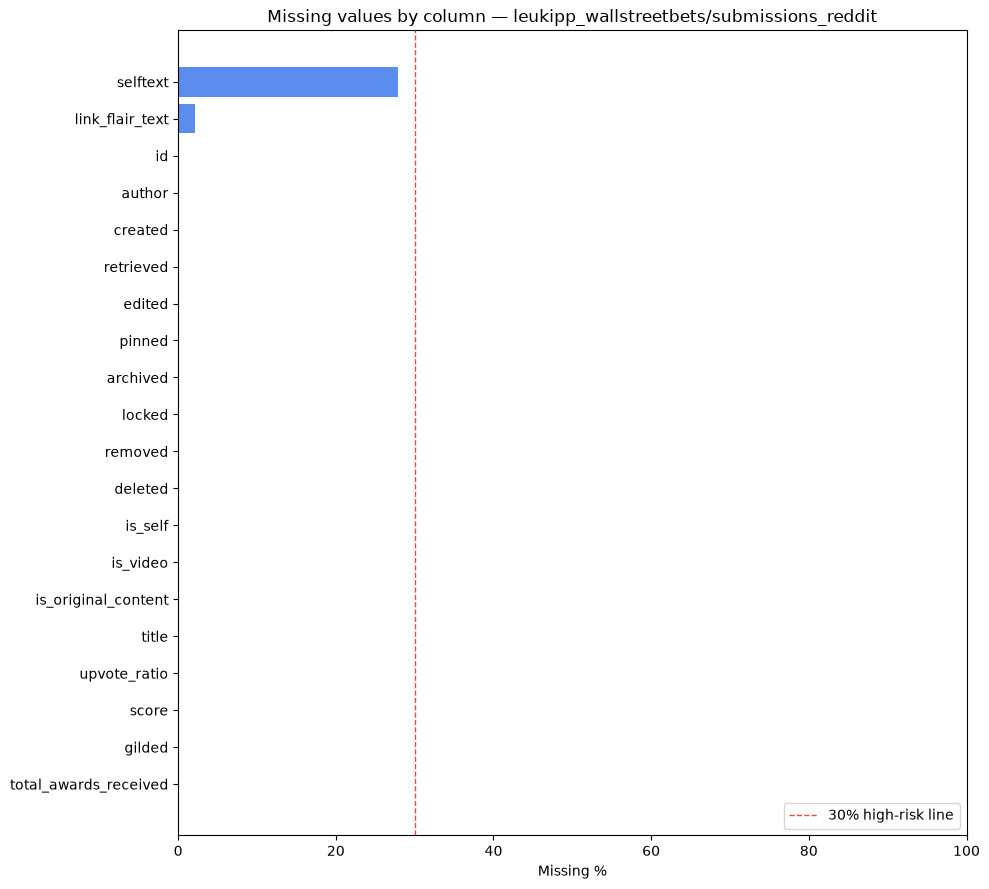

Figures for leukipp_pennystocks/submissions_reddit (recommendation: suitable)


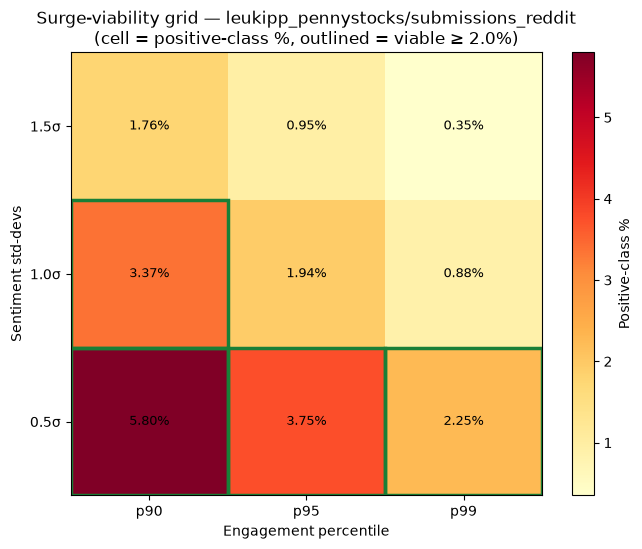

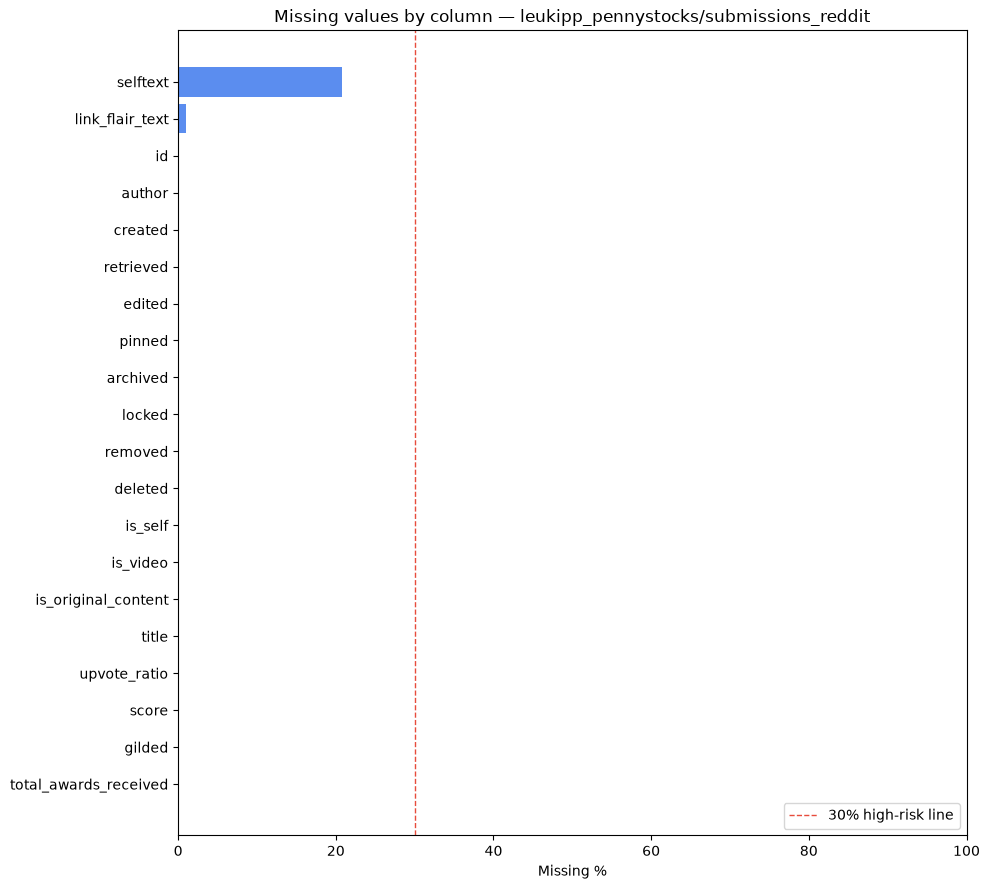

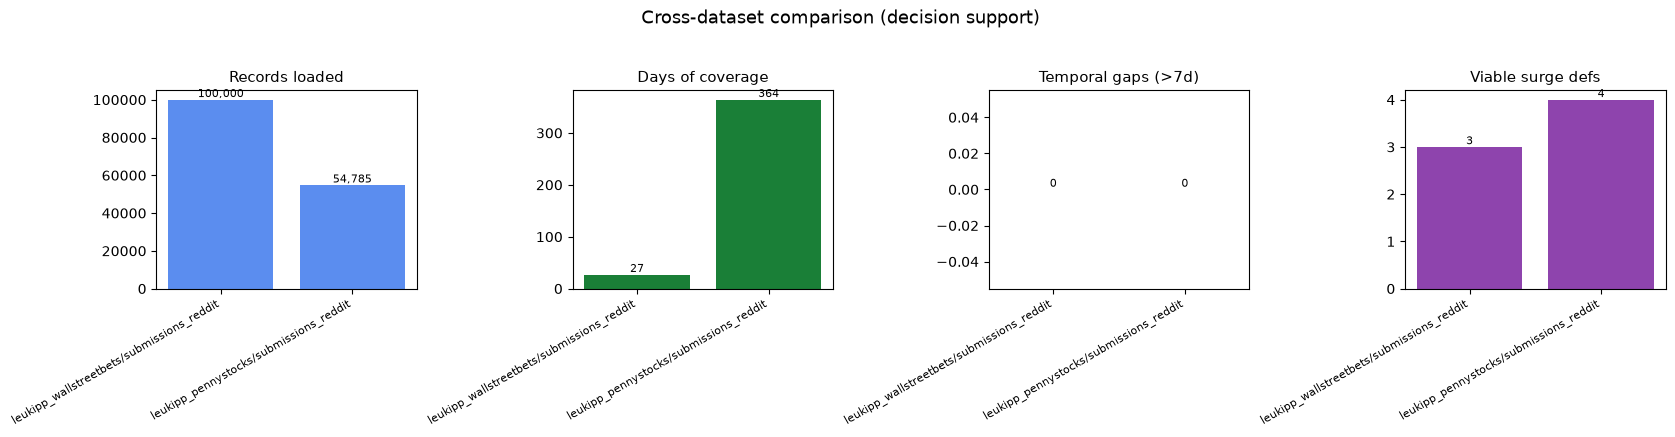


Saved figures to: d:\git\uol-bsc-cm3070-final-project\src\eda\output\figures


In [13]:
# ---------------------------------------------------------------------------
# Render the decision-support figures for every assessed dataset.
# ---------------------------------------------------------------------------
if not _HAS_MPL:
    print("matplotlib not available — skipping figures. Install it and re-run this section.")
elif not assessments:
    print("No assessments — nothing to plot.")
else:
    for a in assessments:
        print(f"Figures for {a['dataset']} (recommendation: {a['recommendation']})")
        plot_surge_viability_heatmap(a)
        plot_missingness(a)

    # One comparison across all assessed datasets.
    plot_cross_dataset_comparison(assessments)

    if SAVE_FIGURES:
        print(f"\nSaved figures to: {FIGURES_DIR}")


---
## 9. Write artifact

In [14]:
# The nested assessments are flattened into a plain table so it saves as a flat CSV.
# There's one row per (dataset, surge definition) pair: the dataset-level facts
# (quality, temporal coverage, reliability, recommendation) repeat on every row,
# and the surge-definition columns change from row to row. Datasets that produced
# no surge definitions still get a single row so they aren't dropped.
flat_rows: list[dict] = []
for a in assessments:
    q, t = a["quality"], a["temporal"]
    cols, rel = a["detected_columns"], a["sentiment_reliability"]
    base = {
        "dataset": a["dataset"],
        "path": a["path"],
        "date_col": cols.get("date"),
        "text_col": cols.get("text"),
        # Lists don't fit in a single cell, so they are joined with a pipe.
        "engagement_cols": "|".join(cols.get("engagement") or []),
        "sentiment_col": cols.get("sentiment"),
        "record_count": q.get("record_count"),
        "column_count": q.get("column_count"),
        "high_risk_columns": "|".join(q.get("high_risk_columns") or []),
        "duplicate_rows": q.get("duplicate_rows"),
        "date_start": t.get("date_range", [None, None])[0],
        "date_end": t.get("date_range", [None, None])[1],
        "total_days": t.get("total_days"),
        "gap_count": t.get("gap_count"),
        "sentiment_agreement_rate": rel.get("agreement_rate"),
        "sentiment_agreement_note": rel.get("note"),
        "viable_surge_count": a.get("viable_surge_count"),
        "surge_fields_ready": a.get("surge_fields_ready"),
        "risks": "|".join(a.get("risks") or []),
        "recommendation": a.get("recommendation"),
        "justification": a.get("justification"),
    }
    surge_defs = a.get("surge_definitions") or [{}]
    for s in surge_defs:
        flat_rows.append({
            **base,
            "engagement_percentile": s.get("engagement_percentile"),
            "sentiment_std_devs": s.get("sentiment_std_devs"),
            "surge_count": s.get("surge_count"),
            "total_posts": s.get("total_posts"),
            "surge_percentage": s.get("surge_percentage"),
            "is_viable": s.get("is_viable"),
        })

# A couple of run-level settings are handy to keep next to the results, so they
# are tucked onto every row as extra columns. A single timestamp is stamped for
# the whole run rather than a slightly different one per row.
generated_at = datetime.now(timezone.utc).isoformat()
for row in flat_rows:
    row["generated_at"] = generated_at
    row["min_positive_class_pct"] = MIN_POSITIVE_CLASS_PCT
    row["full_load_rows"] = FULL_LOAD_ROWS

out_path = OUTPUT_DIR / "deep_assessment.csv"
flat_df = pd.DataFrame(flat_rows)
flat_df.to_csv(out_path, index=False)
print(f"Wrote deep assessment ({len(flat_df)} rows across {len(assessments)} dataset(s)) to: {out_path}")

Wrote deep assessment (18 rows across 2 dataset(s)) to: d:\git\uol-bsc-cm3070-final-project\src\eda\output\deep_assessment.csv


---
## Notes

- Verdict is **decision support**, driven by surge-definition viability (the key criterion for this project). The final pick is made manually.
- For very large datasets, raise `FULL_LOAD_ROWS` deliberately; the default caps runtime.
- Validates the DEC-005 rationale (completeness, volume, ticker diversity) with concrete numbers per dataset.